# Walkers Theory Test

This notebook is divided into two parts: in the first one we will study the behavior of walkers moving naively in 1D space; in the second one we shall delve deeper, and study the dynamics limited by the "collisions" between the two walkers. Notice that these two cases collapse into the same if the walkers share the same probability distribution for the moves, since this would make them *indistinguishable!*

## Part One: Naive Walkers

In [11]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm

In [12]:
# First test: 2 walkers in 1D with absorbant interaction

class Walker():
  def __init__(self, position, left_p, stay_p, right_p):
    self.reset_position = position
    self.position = position
    self.left_p = left_p
    self.stay_p = stay_p
    self.right_p = right_p

  def reset(self):
    self.position = self.reset_position

  def chose_move(self):
    r = np.random.rand()
    if r < self.left_p:
      return -1
    elif r < self.left_p + self.stay_p:
      return 0
    else:
      return 1

  def update_position(self, move):
    self.position += move

def barriers_check(bottom_barrier, top_barrier, walker, candidate_move, reflective_bc):
  if reflective_bc:
    if walker.position + candidate_move < bottom_barrier:
      move = 0
    elif walker.position + candidate_move > top_barrier:
      move = 0
    else:
      move = candidate_move
  else: #periodic_bc
    if walker.position + candidate_move < bottom_barrier:
      move = +top_barrier
    elif walker.position + candidate_move > top_barrier:
      move = -top_barrier
    else:
      move = candidate_move

  return move

def end_game_check(first_walker, second_walker):
  if first_walker.position == second_walker.position:
    return True
  else:
    return False

def play_one_game(bottom_barrier, top_barrier, walker1, walker2, reflective_bc):
  game_lenght = 0
  while not end_game_check(walker1, walker2):
    candidate_move1 = walker1.chose_move()
    candidate_move2 = walker2.chose_move()
    move1 = barriers_check(
        bottom_barrier, top_barrier, walker1, candidate_move1, reflective_bc
        )
    move2 = barriers_check(
        bottom_barrier, top_barrier, walker2, candidate_move2, reflective_bc
        )
    walker1.update_position(move1)
    walker2.update_position(move2)
    game_lenght += 1
  return walker1.position, game_lenght

In [13]:
# Define constants

BOTTOM_BARRIER = 0
TOP_BARRIER = 19
START_POS_1 = 1
START_POS_2 = TOP_BARRIER-1

LEFT_P_1 = 1/3
STAY_P_1 = 1/3
RIGHT_P_1 = 1/3
LEFT_P_2 = 1/3
STAY_P_2 = 1/3
RIGHT_P_2 = 1/3

NUMBER__OF_GAMES = int(1e6)
FREE_PROBABILITY_TRESHOLD_FOR_THEORY_CALC = 1e-8
REFLECTIVE_BOUNDARY_CONDITION = True

In [14]:
# Initialize walkers

walker1 = Walker(START_POS_1, LEFT_P_1, STAY_P_1, RIGHT_P_1)
walker2 = Walker(START_POS_2, LEFT_P_2, STAY_P_2, RIGHT_P_2)

print(f'Walker 1 start position: {walker1.position}')
print(f'Walker 2 start position: {walker2.position}')

# Depict the initial situation

print('\nInitial condition:\n')

for i in range(TOP_BARRIER+1):
  if i == START_POS_1 or i == START_POS_2:
    print('*', end = ' ')
  else:
    print('_', end = ' ')
print()

Walker 1 start position: 1
Walker 2 start position: 18

Initial condition:

_ * _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ * _ 


In [15]:
# Run the numbers:

end_positions = []
times = []

for i in tqdm(range(NUMBER__OF_GAMES)):
  end_position, time = play_one_game(
      BOTTOM_BARRIER, TOP_BARRIER, walker1, walker2, REFLECTIVE_BOUNDARY_CONDITION
      )
  walker1.reset()
  walker2.reset()
  end_positions.append(end_position)
  times.append(time)

mean_absorbtion_time = np.mean(times)

print(f'The mean absorbtion time is {mean_absorbtion_time}')

  0%|          | 0/1000000 [00:00<?, ?it/s]

The mean absorbtion time is 183.317975


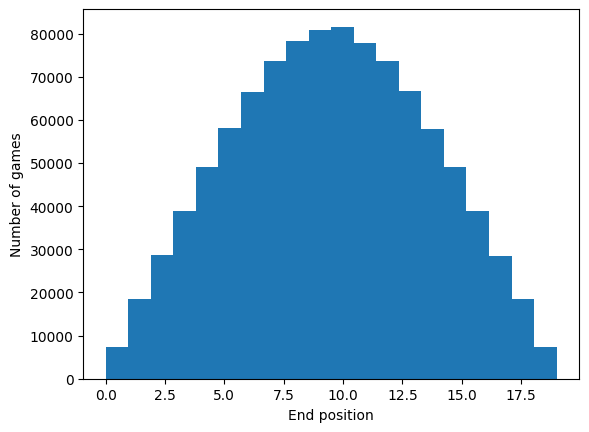

In [16]:
# Make histogram of end positions

number_of_sites = TOP_BARRIER - BOTTOM_BARRIER + 1

plt.hist(end_positions, bins = number_of_sites)
plt.xlabel('End position')
plt.ylabel('Number of games')
plt.show()

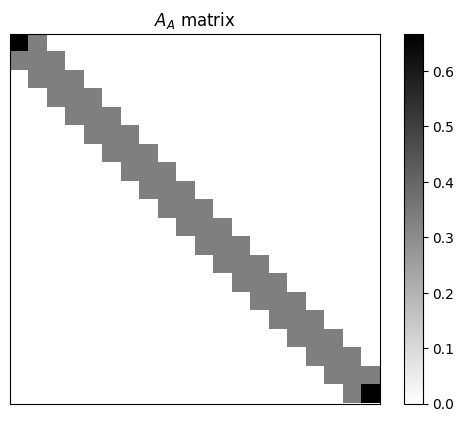

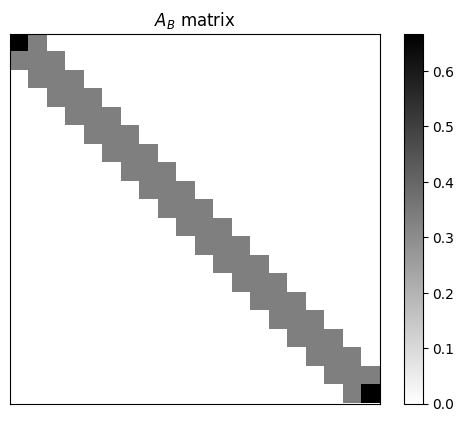

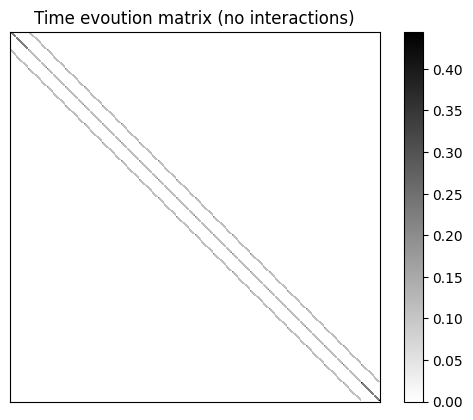

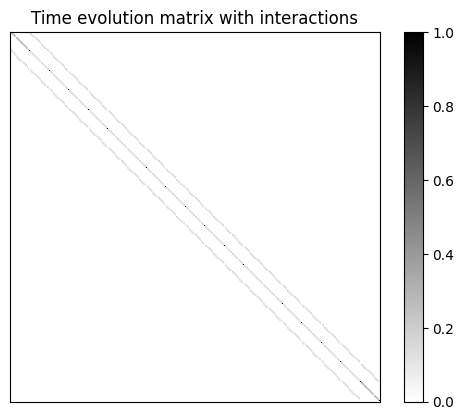

In [17]:
# GET THE THEORETICAL CURVE

# Define the time evolution matrices:

A_1 = np.zeros((number_of_sites, number_of_sites))
np.fill_diagonal(A_1, STAY_P_1)
np.fill_diagonal(A_1[1:], RIGHT_P_1)
np.fill_diagonal(A_1[:, 1:], LEFT_P_1)
if REFLECTIVE_BOUNDARY_CONDITION:
  A_1[0,0] = STAY_P_1 + LEFT_P_1
  A_1[number_of_sites-1, number_of_sites-1] = STAY_P_1 + RIGHT_P_1
else: #Periodic BC
  A_1[number_of_sites-1, 0] = LEFT_P_1
  A_1[0, number_of_sites-1] = RIGHT_P_1

# Plot A_1 matrix

plt.imshow(A_1, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('$A_A$ matrix')
plt.xticks([])
plt.yticks([])
plt.show()

A_2 = np.zeros((number_of_sites, number_of_sites))
np.fill_diagonal(A_2, STAY_P_2)
np.fill_diagonal(A_2[1:], RIGHT_P_2)
np.fill_diagonal(A_2[:, 1:], LEFT_P_2)
if REFLECTIVE_BOUNDARY_CONDITION:
  A_2[0,0] = STAY_P_2 + LEFT_P_2
  A_2[number_of_sites-1, number_of_sites-1] = STAY_P_2 + RIGHT_P_2
else: #Periodic BC
  A_2[number_of_sites-1, 0] = LEFT_P_2
  A_2[0, number_of_sites-1] = RIGHT_P_2

# Plot A_2 matrix

plt.imshow(A_2, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('$A_B$ matrix')
plt.xticks([])
plt.yticks([])
plt.show()

# Get the global A matrix (that is the tensor product)

A_no_int = np.kron(A_1, A_2)

# Plot A matrix

plt.imshow(A_no_int, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('Time evoution matrix (no interactions)')
plt.xticks([])
plt.yticks([])
plt.show()

# Insert interactions by replacing the columns with index: i + (i-1)*number_of_sites -1
# with the identity column
# (Notice the -1, it is there because the index start from 0 and not from 1)

trap_indices_list = [i + (i-1)*number_of_sites - 1 for i in range(1, number_of_sites+1)]

A = np.copy(A_no_int)

for index in trap_indices_list:
  A[:, index] = np.eye(number_of_sites**2)[:, index]

# Plot A matrix as table of squares

plt.imshow(A, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('Time evolution matrix with interactions')
plt.xticks([])
plt.yticks([])
plt.show()

In [18]:
# Specifing the start distribution

P0_1 = np.zeros(number_of_sites)
P0_1[START_POS_1] = 1

P0_2 = np.zeros(number_of_sites)
P0_2[START_POS_2] = 1

# General P0

P0 = np.kron(P0_1, P0_2)

In [19]:
# Calculate time evolution, and so the capture probability on sites (cursive P)

Pt = np.matmul(A, P0)

delta_iterations_for_check = 100
iterations = 0

while True:

  Pt = np.dot(A, Pt)

  Cursive_Pts = []

  for index in trap_indices_list:
    Cursive_Pts.append(Pt[index])

  # Check probability mass trapped

  trapped_prob_mass = sum(Cursive_Pts)

  if iterations % delta_iterations_for_check == 0:
    print(f'Trapped probability mass at iteration {iterations}: {trapped_prob_mass}')

  if 1 - trapped_prob_mass < FREE_PROBABILITY_TRESHOLD_FOR_THEORY_CALC:
    break
  else:
    iterations += 1

Trapped probability mass at iteration 0: 0.0
Trapped probability mass at iteration 100: 0.30677540219073063
Trapped probability mass at iteration 200: 0.6742646380995969
Trapped probability mass at iteration 300: 0.8502910000119729
Trapped probability mass at iteration 400: 0.9312592969749971
Trapped probability mass at iteration 500: 0.968438194988274
Trapped probability mass at iteration 600: 0.985508648157936
Trapped probability mass at iteration 700: 0.9933464115451595
Trapped probability mass at iteration 800: 0.9969450580142857
Trapped probability mass at iteration 900: 0.9985973477923943
Trapped probability mass at iteration 1000: 0.9993559834443015
Trapped probability mass at iteration 1100: 0.9997043049433286
Trapped probability mass at iteration 1200: 0.9998642339769557
Trapped probability mass at iteration 1300: 0.9999376641151133
Trapped probability mass at iteration 1400: 0.9999713789764338
Trapped probability mass at iteration 1500: 0.9999868588856698
Trapped probability 

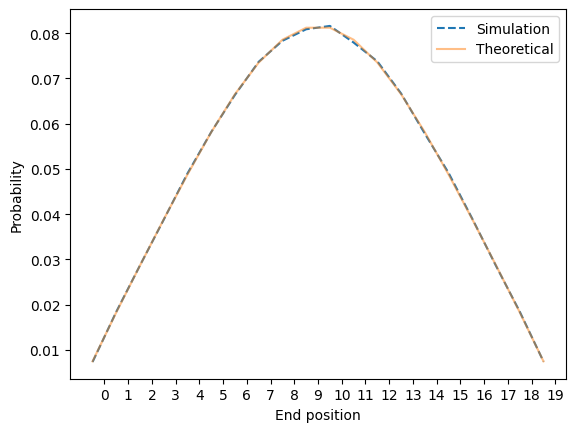

In [20]:
# Plot experimental probs and theoretical probs

# Exp probs

exp_probs = []

for i in range(number_of_sites):
  exp_probs.append(end_positions.count(i)/NUMBER__OF_GAMES)

plt.plot(exp_probs, label = 'Simulation', linestyle = '--')

# Theoretical probs

plt.plot(Cursive_Pts, label = 'Theoretical', alpha = 0.5)
plt.xlabel('End position')
plt.ylabel('Probability')

# Plot xticks 0,1,2... in position 0.5,1,1.5...
plt.xticks([i+1/2 for i in range(number_of_sites)], [i for i in range(number_of_sites)])

plt.legend()
plt.show()

In [21]:
# Calculate theoretical mean absorbtion time

A_modded = np.copy(A)

for index in trap_indices_list:
  A_modded[:, index] = np.zeros(number_of_sites**2)

c_vector = np.ones(number_of_sites**2)

for index in trap_indices_list:
  c_vector[index] = 0

main_matrix = np.linalg.inv(np.eye(number_of_sites**2) - np.transpose(A_modded))

time_vector =np.matmul(main_matrix, c_vector)

start_configuration_index = np.argmax(P0)

theoretical_mean_absorbtion_time = time_vector[start_configuration_index]

print(f'The theoretical mean absorbtion time is {theoretical_mean_absorbtion_time}')

prediction_difference = np.abs(theoretical_mean_absorbtion_time - mean_absorbtion_time)

print(f'The prediction difference is {prediction_difference}')


The theoretical mean absorbtion time is 183.3657683458422
The prediction difference is 0.047793345842222834


## Part Two: Walking without forbidden processes

In [22]:
# Let's re-run, modifying the interaction to make it non compenetrating

# For the simulation we just need to define a new check function
# For now we are implementing stopping collisions: meaning that all the probability mass
# of the compenetration goes to the 'stillness case'

def non_comp_barriers_check(
    bottom_barrier, top_barrier, walker1, walker2, candidate_move1, candidate_move2, reflective_bc
    ):

  compenetration_warning = False

  if reflective_bc:
    if walker1.position + candidate_move1 < bottom_barrier:
      move1 = 0
    elif walker1.position + candidate_move1 > top_barrier:
      move1 = 0
    else:
      move1 = candidate_move1

    if walker2.position + candidate_move2 < bottom_barrier:
      move2 = 0
    elif walker2.position + candidate_move2 > top_barrier:
      move2 = 0
    else:
      move2 = candidate_move2
  else:
    if walker1.position + candidate_move1 < bottom_barrier:
      move1 = +top_barrier
    elif walker1.position + candidate_move1 > top_barrier:
      move1 = -top_barrier
    else:
      move1 = candidate_move1

    if walker2.position + candidate_move2 < bottom_barrier:
      move2 = +top_barrier
    elif walker2.position + candidate_move2 > top_barrier:
      move2 = -top_barrier
    else:
      move2 = candidate_move2

  if walker1.position + move1 == walker2.position and walker2.position + move2 == walker1.position:
    move1 = 0
    move2 = 0
    compenetration_warning = True

  return move1, move2, compenetration_warning

def play_one_game_non_comp(bottom_barrier, top_barrier, walker1, walker2, reflective_bc):
  game_lenght = 0
  compenetrations_prevented = 0
  game_affected_by_comp = False
  while not end_game_check(walker1, walker2):
    candidate_move1 = walker1.chose_move()
    candidate_move2 = walker2.chose_move()
    move1, move2, comp_warning = non_comp_barriers_check(
        bottom_barrier, top_barrier, walker1, walker2, candidate_move1, candidate_move2, reflective_bc
        )
    walker1.update_position(move1)
    walker2.update_position(move2)
    game_lenght += 1
    if comp_warning:
      compenetrations_prevented += 1
      game_affected_by_comp = True
  return walker1.position, game_lenght, compenetrations_prevented, game_affected_by_comp

In [23]:
# Run the numbers with new collision dynamic

end_positions_non_comp = []
times_non_comp = []
compenetrations_prevented = 0
games_affected_by_comp = 0

for i in tqdm(range(NUMBER__OF_GAMES)):
  end_position, time, this_game_comps_prev, game_with_comp = play_one_game_non_comp(
      BOTTOM_BARRIER, TOP_BARRIER, walker1, walker2, REFLECTIVE_BOUNDARY_CONDITION
      )
  walker1.reset()
  walker2.reset()
  end_positions_non_comp.append(end_position)
  times_non_comp.append(time)
  compenetrations_prevented += this_game_comps_prev
  if game_with_comp:
    games_affected_by_comp += 1

mean_absorbtion_time = np.mean(times)

print(f'The mean absorbtion time in the non compenetration case is {mean_absorbtion_time}')
print(f'The number of compenetrations prevented is: {compenetrations_prevented}')

percent_games_affected_by_comp = games_affected_by_comp/NUMBER__OF_GAMES * 100

print(f'The percentage of games affected by compenetration is: {percent_games_affected_by_comp}%')

  0%|          | 0/1000000 [00:00<?, ?it/s]

The mean absorbtion time in the non compenetration case is 183.317975
The number of compenetrations prevented is: 287260
The percentage of games affected by compenetration is: 21.078%


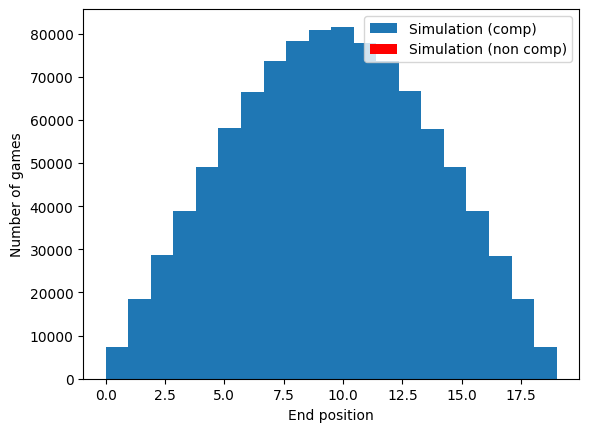

In [24]:
# Drawing new histogram (non comp) and old histogram (comp) on top of one another

plt.hist(end_positions, bins = number_of_sites, label = 'Simulation (comp)')
plt.hist(end_positions_non_comp, bins = number_of_sites, density = True, label = 'Simulation (non comp)', color='red')

plt.xlabel('End position')
plt.ylabel('Number of games')

plt.legend()
plt.show()

A is normalized
Found forbidden process: (1,2) to (2,1); corresponding indices: (2,21)
Found forbidden process: (2,3) to (3,2); corresponding indices: (23,42)
Found forbidden process: (3,4) to (4,3); corresponding indices: (44,63)
Found forbidden process: (4,5) to (5,4); corresponding indices: (65,84)
Found forbidden process: (5,6) to (6,5); corresponding indices: (86,105)
Found forbidden process: (6,7) to (7,6); corresponding indices: (107,126)
Found forbidden process: (7,8) to (8,7); corresponding indices: (128,147)
Found forbidden process: (8,9) to (9,8); corresponding indices: (149,168)
Found forbidden process: (9,10) to (10,9); corresponding indices: (170,189)
Found forbidden process: (10,11) to (11,10); corresponding indices: (191,210)
Found forbidden process: (11,12) to (12,11); corresponding indices: (212,231)
Found forbidden process: (12,13) to (13,12); corresponding indices: (233,252)
Found forbidden process: (13,14) to (14,13); corresponding indices: (254,273)
Found forbidde

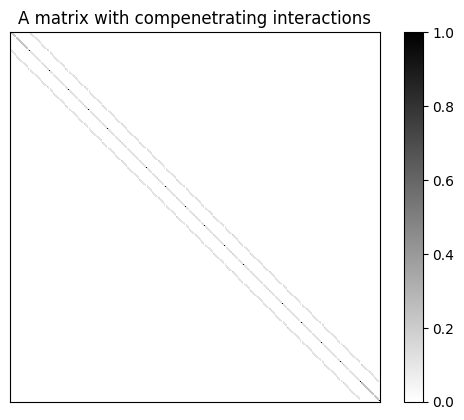

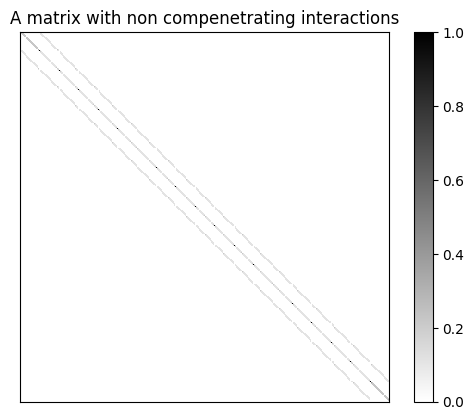

In [28]:
# Make the theory curve for the non compenetration case

# We need to mod A

# Check A column normalization (only the column of a transfer matrix must be normalized)

normalization = True
tolerance = 1e-10

for i in range(number_of_sites**2):
  if np.sum(A[:, i]) - 1 > tolerance:
    print(f'Column {i} sums to {np.sum(A[:, i])}')
    normalization = False

if normalization:
  print('A is normalized')
else:
  print('A is not normalized')

A_non_comp = np.copy(A)

indices_i_switch_processes = []
indices_j_switch_processes = []

#-------------------------------------------------------------------------------
# Finding indexes of forbidden processes

for k in range(1, number_of_sites):
  current_i = k+1+(k-1)*number_of_sites
  current_j = k+k*number_of_sites
  indices_i_switch_processes.append(current_i)
  indices_j_switch_processes.append(current_j)
  print(f'Found forbidden process: ({k},{k+1}) to ({k+1},{k}); corresponding indices: ({current_i},{current_j})')

for k in range(2, number_of_sites+1):
  current_i = k-1+(k-1)*number_of_sites
  current_j = k+(k-2)*number_of_sites
  indices_i_switch_processes.append(current_i)
  indices_j_switch_processes.append(current_j)
  print(f'Found forbidden process: ({k},{k-1}) to ({k-1},{k}); corresponding indices: ({current_i},{current_j})')

current_i = 1+(number_of_sites-1)*number_of_sites
current_j = number_of_sites
indices_i_switch_processes.append(current_i)
indices_j_switch_processes.append(current_j)
print(
    f'Found forbidden process: (1,{number_of_sites}) to ({number_of_sites},1); corresponding indices: ({current_i},{current_j})'
    )

current_i = number_of_sites
current_j = 1+(number_of_sites-1)*number_of_sites
indices_i_switch_processes.append(current_i)
indices_j_switch_processes.append(current_j)
print(
    f'Found forbidden process: ({number_of_sites},1) to (1,{number_of_sites}); corresponding indices: ({current_i},{current_j})'
    )

#-------------------------------------------------------------------------------

number_of_transfers_needed = len(indices_i_switch_processes)

# -1 slide to conform to cs indices

for i in range(number_of_transfers_needed):
  indices_i_switch_processes[i] -= 1
  indices_j_switch_processes[i] -= 1

indices_i_still_processes = indices_j_switch_processes.copy()
indices_j_still_processes = indices_j_switch_processes.copy()

# Perform the transfer of probability mass

for i in range(number_of_transfers_needed):

  A_non_comp[indices_i_still_processes[i], indices_j_still_processes[i]] += \
    A_non_comp[indices_i_switch_processes[i], indices_j_switch_processes[i]]

  A_non_comp[indices_i_switch_processes[i], indices_j_switch_processes[i]] = 0

# Check the normalization of the new A

normalization = True
tolerance = 1e-10

for i in range(number_of_sites**2):
  if np.sum(A_non_comp[:, i]) - 1 > tolerance:
    print(f'Column {i} sums to {np.sum(A_non_comp[:, i])}')
    normalization = False

if normalization:
  print('A without compenetrations is normalized')
else:
  print('A without compenetrations is not normalized')

# Plot before and after comparison

plt.imshow(A, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A matrix with compenetrating interactions')
plt.xticks([])
plt.yticks([])
plt.show()

plt.imshow(A_non_comp, interpolation='nearest', cmap='binary')
plt.colorbar()
plt.title('A matrix with non compenetrating interactions')
plt.xticks([])
plt.yticks([])
plt.show()

In [26]:
# Calculate theory curve for non comp case

Pt_non_comp = np.matmul(A_non_comp, P0)

delta_iterations_for_check = 1000
iteration = 0

while True:

  Pt_non_comp = np.matmul(A_non_comp, Pt_non_comp)

  Cursive_Pts_non_comp = []

  for index in trap_indices_list:
    Cursive_Pts_non_comp.append(Pt_non_comp[index])

  # Check probability mass trapped

  trapped_prob_mass = sum(Cursive_Pts_non_comp)

  if iteration % delta_iterations_for_check == 0:
    print(f'Trapped probability mass at iteration {iteration}: {trapped_prob_mass}')

  if 1 - trapped_prob_mass < FREE_PROBABILITY_TRESHOLD_FOR_THEORY_CALC:
    break
  else:
    iteration += 1

Trapped probability mass at iteration 0: 0.0
Trapped probability mass at iteration 1000: 0.9993559834443018
Trapped probability mass at iteration 2000: 0.9999997318564394


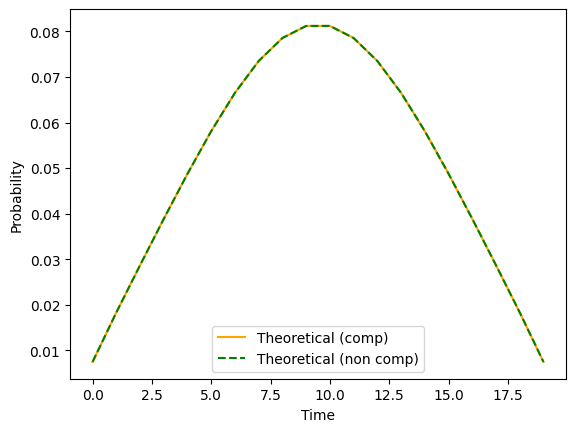

In [27]:
# Plot the two theory curves

plt.plot(Cursive_Pts, label = 'Theoretical (comp)', color = 'orange')
plt.plot(Cursive_Pts_non_comp, label = 'Theoretical (non comp)', color = 'green', linestyle = '--')
plt.xlabel('Time')
plt.ylabel('Probability')
plt.legend()
plt.show()